# Experiment 2: So sánh ba mô hình học máy Logistic Regression, Naive Bayes và SVM và ta sẽ sử dụng kỹ thuật tìm siêu tham số (hyperparameters) cho mô hình tốt nhất

In [4]:
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.svm import LinearSVC

from sklearn.metrics import accuracy_score, classification_report

In [5]:
df = pd.read_csv("../data/processed/IMDB Processed.csv")

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    df["review"],
    df["sentiment"],
    test_size=0.2,
    random_state=42
)

### Load Term Frequency-Inverse Document Frequency model (TFIDF)

In [ ]:
tfidf = joblib.load("../models/tfidf.pkl")

In [10]:
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

### Logistic Regression

In [11]:
lr_model = LogisticRegression( max_iter=1000, solver="liblinear", C=1.0)
lr_model.fit(X_train_tfidf, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [12]:
print("Train accuracy:", lr_model.score(X_train_tfidf, y_train))
print("Test accuracy:", lr_model.score(X_test_tfidf, y_test))

Train accuracy: 0.9412773253321903
Test accuracy: 0.8937071399757966


In [13]:
lr_pred = lr_model.predict(X_test_tfidf)

In [40]:
joblib.dump(lr_model, "../models/lr_model.pkl")

['../models/lr_model.pkl']

### Naive Bayes

In [14]:
nb_model = MultinomialNB(alpha = 1.0)
nb_model.fit(X_train_tfidf, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [15]:
print("Train accuracy:", nb_model.score(X_train_tfidf, y_train))
print("Test accuracy:", nb_model.score(X_test_tfidf, y_test))

Train accuracy: 0.91293714228083
Test accuracy: 0.8792860024203307


In [16]:
nb_pred = nb_model.predict(X_test_tfidf)

In [39]:
joblib.dump(nb_model, "../models/nb_model.pkl")

['../models/nb_model.pkl']

### Linear SVM

In [29]:
svm_model = LinearSVC(C = 0.1)
svm_model.fit(X_train_tfidf, y_train)

,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",0.1
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo rand

In [34]:
print("Train accuracy:", svm_model.score(X_train_tfidf, y_train))
print("Test accuracy:", svm_model.score(X_test_tfidf, y_test))

Train accuracy: 0.944076044476942
Test accuracy: 0.8953206938281565


In [35]:
svm_pred = svm_model.predict(X_test_tfidf)

In [38]:
joblib.dump(svm_model, "../models/svm_model.pkl")

['../models/svm_model.pkl']

### So sánh

In [36]:
lr_acc = accuracy_score(y_test, lr_pred)
nb_acc = accuracy_score(y_test, nb_pred)
svm_acc = accuracy_score(y_test, svm_pred)
# Model Comparison Summary
print("\n===== COMPARISON =====")
print(f"Logistic Regression: {lr_acc*100:.2f}%")
print(f"Naive Bayes: {nb_acc*100:.2f}%")
print(f"SVM: {svm_acc*100:.2f}%")


===== COMPARISON =====
Logistic Regression: 89.37%
Naive Bayes: 87.93%
SVM: 89.53%


Vì SVM có chỉ số cao nhất nên ta sẽ sử dụng kỹ thuật tìm siêu tham số (hyperparameters) tốt nhất

In [44]:
svm = joblib.load("../models/svm_model.pkl")

In [46]:
# Hyperparameter Tuning (GridSearch for SVM)
param_grid = {
    'C': [0.1, 1, 10, 100],
    'loss': ['hinge', 'squared_hinge']
}

grid = GridSearchCV(svm, param_grid, refit=True, verbose=2)
grid.fit(X_train_tfidf, y_train)

print("Best CV Score: {:.2f}".format(grid.best_score_))
print("Best Parameters:", grid.best_params_)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
[CV] END ..................................C=0.1, loss=hinge; total time=   0.2s
[CV] END ..................................C=0.1, loss=hinge; total time=   0.2s
[CV] END ..................................C=0.1, loss=hinge; total time=   0.2s
[CV] END ..................................C=0.1, loss=hinge; total time=   0.2s
[CV] END ..................................C=0.1, loss=hinge; total time=   0.2s
[CV] END ..........................C=0.1, loss=squared_hinge; total time=   0.3s
[CV] END ..........................C=0.1, loss=squared_hinge; total time=   0.3s
[CV] END ..........................C=0.1, loss=squared_hinge; total time=   0.3s
[CV] END ..........................C=0.1, loss=squared_hinge; total time=   0.3s
[CV] END ..........................C=0.1, loss=squared_hinge; total time=   0.3s
[CV] END ....................................C=1, loss=hinge; total time=   0.8s
[CV] END ....................................C=1,

c:\Users\Administrator\Downloads\sentiment-analysis\venv\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


[CV] END ..................................C=100, loss=hinge; total time=  11.6s
[CV] END ..................................C=100, loss=hinge; total time=   3.2s


c:\Users\Administrator\Downloads\sentiment-analysis\venv\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


[CV] END ..........................C=100, loss=squared_hinge; total time=  15.9s
[CV] END ..........................C=100, loss=squared_hinge; total time=   2.2s


c:\Users\Administrator\Downloads\sentiment-analysis\venv\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


[CV] END ..........................C=100, loss=squared_hinge; total time=  12.5s
[CV] END ..........................C=100, loss=squared_hinge; total time=   9.6s
[CV] END ..........................C=100, loss=squared_hinge; total time=   3.6s
Best CV Score: 0.90
Best Parameters: {'C': 1, 'loss': 'hinge'}


In [49]:
# Train Final Optimized SVM
best_svc = LinearSVC(C=grid.best_params_['C'], loss=grid.best_params_['loss'])
best_svc.fit(X_train_tfidf, y_train)

best_pred = best_svc.predict(X_test_tfidf)
best_acc = accuracy_score(y_test, best_pred)

print("Optimized SVM Accuracy: {:.2f}%".format(best_acc * 100))

print(confusion_matrix(y_test, best_pred))
print("\n", classification_report(y_test, best_pred))
print("Train accuracy:", best_svc.score(X_train_tfidf, y_train))
print("Test accuracy:", best_svc.score(X_test_tfidf, y_test))

Optimized SVM Accuracy: 89.83%
[[4369  544]
 [ 464 4539]]

               precision    recall  f1-score   support

           0       0.90      0.89      0.90      4913
           1       0.89      0.91      0.90      5003

    accuracy                           0.90      9916
   macro avg       0.90      0.90      0.90      9916
weighted avg       0.90      0.90      0.90      9916

Train accuracy: 0.9714581074607297
Test accuracy: 0.8983461073013311


In [50]:
# Model Comparison Summary
print("\n===== FINAL COMPARISON =====")
print(f"Logistic Regression: {lr_acc*100:.2f}%")
print(f"Naive Bayes: {nb_acc*100:.2f}%")
print(f"SVM: {svm_acc*100:.2f}%")
print(f"Optimized SVM: {best_acc*100:.2f}%")


===== FINAL COMPARISON =====
Logistic Regression: 89.37%
Naive Bayes: 87.93%
SVM: 89.53%
Optimized SVM: 89.83%


In [51]:
joblib.dump(best_svc, '../models/best_svm_model.pkl')

['../models/best_svm_model.pkl']

In [52]:
def evaluate_model(name, y_test, y_pred, train_time):
    report = classification_report(y_test, y_pred, output_dict=True)
    
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": report["weighted avg"]["precision"],
        "Recall": report["weighted avg"]["recall"],
        "F1-score": report["weighted avg"]["f1-score"],
        "Train time (s)": train_time
    }

In [53]:
import time

# Logistic Regression
start = time.time()
lr_model.fit(X_train_tfidf, y_train)
time_logreg = time.time() - start
logreg_pred = lr_model.predict(X_test_tfidf)

# Naive Bayes
start = time.time()
nb_model.fit(X_train_tfidf, y_train)
time_mnb = time.time() - start
mnb_pred = nb_model.predict(X_test_tfidf)

# SVM
start = time.time()
svm_model.fit(X_train_tfidf, y_train)
time_svc = time.time() - start
svc_pred = svm_model.predict(X_test_tfidf)

# GridSearch SVM
start = time.time()
grid.fit(X_train_tfidf, y_train)
time_best_svm = time.time() - start
best_svc = grid.best_estimator_
best_pred = best_svc.predict(X_test_tfidf)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
[CV] END ..................................C=0.1, loss=hinge; total time=   0.2s
[CV] END ..................................C=0.1, loss=hinge; total time=   0.2s
[CV] END ..................................C=0.1, loss=hinge; total time=   0.2s
[CV] END ..................................C=0.1, loss=hinge; total time=   0.2s
[CV] END ..................................C=0.1, loss=hinge; total time=   0.2s
[CV] END ..........................C=0.1, loss=squared_hinge; total time=   0.3s
[CV] END ..........................C=0.1, loss=squared_hinge; total time=   0.3s
[CV] END ..........................C=0.1, loss=squared_hinge; total time=   0.3s
[CV] END ..........................C=0.1, loss=squared_hinge; total time=   0.5s
[CV] END ..........................C=0.1, loss=squared_hinge; total time=   0.6s
[CV] END ....................................C=1, loss=hinge; total time=   1.0s
[CV] END ....................................C=1,

c:\Users\Administrator\Downloads\sentiment-analysis\venv\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


[CV] END ..................................C=100, loss=hinge; total time=  12.7s
[CV] END ..................................C=100, loss=hinge; total time=   2.6s


c:\Users\Administrator\Downloads\sentiment-analysis\venv\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


[CV] END ..........................C=100, loss=squared_hinge; total time=  11.7s
[CV] END ..........................C=100, loss=squared_hinge; total time=   1.9s


c:\Users\Administrator\Downloads\sentiment-analysis\venv\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


[CV] END ..........................C=100, loss=squared_hinge; total time=  11.8s
[CV] END ..........................C=100, loss=squared_hinge; total time=   9.2s
[CV] END ..........................C=100, loss=squared_hinge; total time=   5.0s


In [54]:
results = []

results.append(evaluate_model("Logistic Regression", y_test, logreg_pred, time_logreg))
results.append(evaluate_model("Naive Bayes", y_test, mnb_pred, time_mnb))
results.append(evaluate_model("SVM (LinearSVC)", y_test, svc_pred, time_svc))
results.append(evaluate_model("Best SVM (GridSearch)", y_test, best_pred, time_best_svm))

df_results = pd.DataFrame(results)
df_results

,Model,Accuracy,Precision,Recall,F1-score,Train time (s)
0,Logistic Regression,0.893707,0.894003,0.893707,0.893672,1.688387
1,Naive Bayes,0.879286,0.879530,0.879286,0.879250,0.051254
2,SVM (LinearSVC),0.895321,0.895664,0.895321,0.895282,0.572716
3,Best SVM (GridSearch),0.898346,0.898435,0.898346,0.898332,149.659132


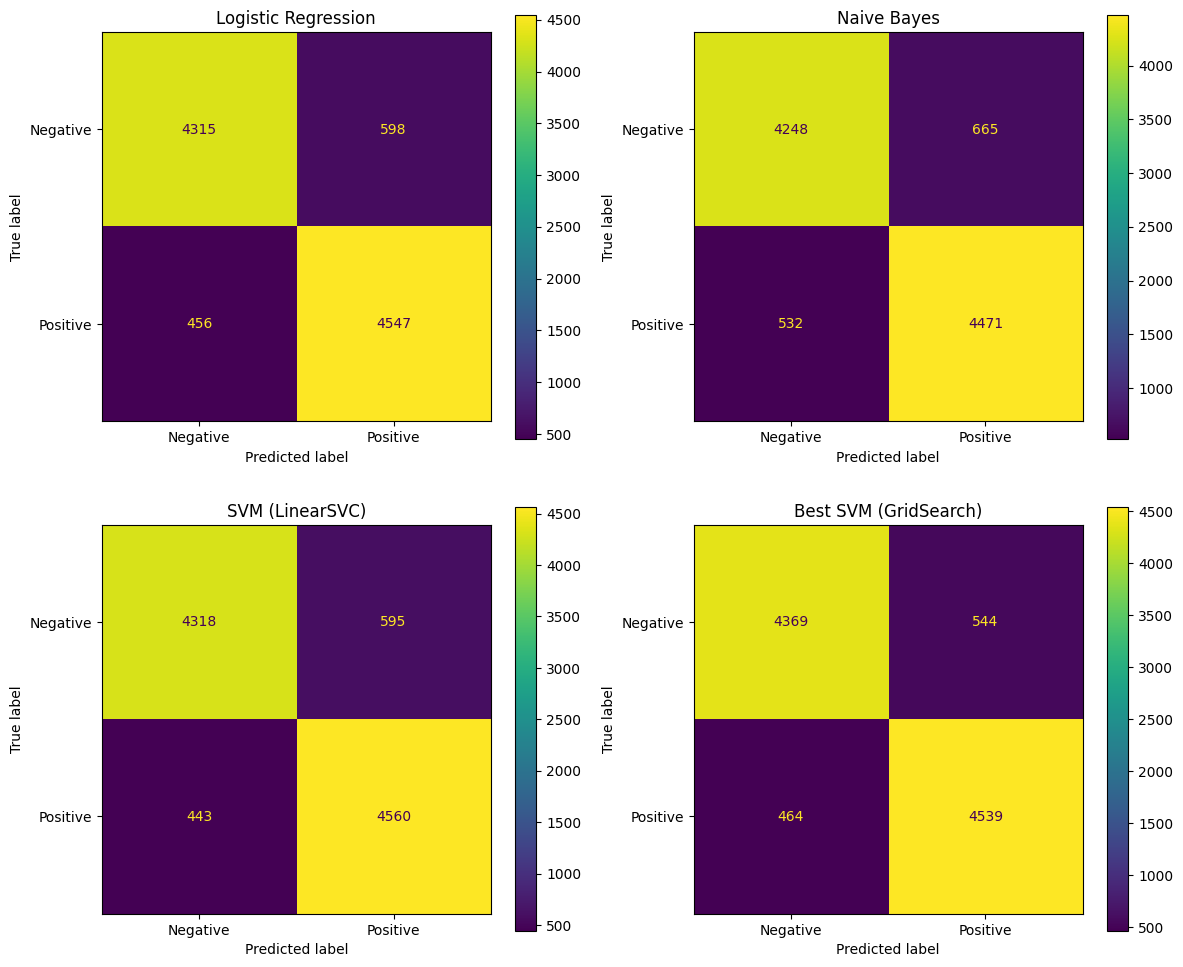

In [58]:
import matplotlib.pyplot as plt

labels = ["Negative", "Positive"]  # hoặc theo thứ tự label của bạn

cm_logreg = confusion_matrix(y_test, logreg_pred)
cm_nb = confusion_matrix(y_test, mnb_pred)
cm_svm = confusion_matrix(y_test, svc_pred)
cm_best = confusion_matrix(y_test, best_pred)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

ConfusionMatrixDisplay(cm_logreg, display_labels=labels).plot(ax=axes[0,0], values_format='d')
axes[0,0].set_title("Logistic Regression")

ConfusionMatrixDisplay(cm_nb, display_labels=labels).plot(ax=axes[0,1], values_format='d')
axes[0,1].set_title("Naive Bayes")

ConfusionMatrixDisplay(cm_svm, display_labels=labels).plot(ax=axes[1,0], values_format='d')
axes[1,0].set_title("SVM (LinearSVC)")

ConfusionMatrixDisplay(cm_best, display_labels=labels).plot(ax=axes[1, 1], values_format='d')
axes[1, 1].set_title("Best SVM (GridSearch)")

cm_logreg = confusion_matrix(y_test, logreg_pred, normalize='true')

plt.tight_layout()
plt.show()

In [59]:
import re
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def data_processing(text):
    text = text.lower()
    text = re.sub('<br />', '', text)
    text = re.sub(r"http\S+|www\S+|https\S+", '', text)
    text = re.sub(r'[^\w\s]', '', text)

    text_tokens = re.findall(r'\b\w+\b', text)

    filtered_text = [w for w in text_tokens if w not in stop_words]

    return " ".join(filtered_text)

In [61]:
while True:
    review = input("Nhập review (gõ 'exit' để thoát): ")
    
    if review.lower() == 'exit':
        break
    
    try:
        review_processed = data_processing(review)
    except:
        review_processed = review.lower()
    
    vec = tfidf.transform([review_processed])
    pred = best_svc.predict(vec)[0]
    
    if pred == 1:
        print(review, ": Positive")
    else:
        print(review, ": Negative ")

This movie is amazing, I really love it : Positive
One of the best movies I have ever seen : Positive
I hate this film, it was a waste of time : Negative 
The story is bad and acting is worse : Negative 
The story is bad and acting is worse : Negative 
It’s not a good movie, but I still enjoyed it : Positive
